# COSC2753 | Machine Learning

## Task 2: Season Classification

# 1. Introduction

This notebook is the Task 2 starter experiment. **Notebook outputs are intentionally cleared. The existing checkpoint is a prototype used for application testing, not the final investigation. Member 3 must run both controlled candidates, complete every analysis prompt, and replace the mock checkpoint.** Season can be subjective and weakly visible, so evaluation emphasizes macro F1, calibration, article-type confounding, and representative failures rather than accuracy alone.

# 2. Library Imports and Setup

In [1]:
from copy import deepcopy
from pathlib import Path
import json, sys, time

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'scripts'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

from app.server.utils.classifier import FashionClassifier
from app.server.utils.handcrafted import DEFAULT_FEATURE_CONFIG, handcrafted_feature
from evaluation import calibration_table, expected_calibration_error, high_confidence_errors, ordered_estimator_probabilities, saved_model_robustness, select_validation_candidate, subgroup_metrics
from preprocessing import IMAGE_SIZE, NORMALISATION_PATH, SEED, seed_everything, select_torch_device, task_frame
seed_everything(SEED); torch.manual_seed(SEED)
DEVICE = select_torch_device()
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
DEVICE

Using CUDA: NVIDIA GeForce RTX 4060 Ti | PyTorch 2.11.0+cu128 | CUDA 12.8


device(type='cuda')

# 3. Frozen Data and Season EDA

In [2]:
TARGET = 'season'
train_df = task_frame(TARGET, 'train')
validation_df = task_frame(TARGET, 'validation')
test_df = task_frame(TARGET, 'test')
with NORMALISATION_PATH.open(encoding='utf-8') as handle:
    normalisation = json.load(handle)
labels = sorted(train_df[TARGET].unique())
label_to_index = {label: index for index, label in enumerate(labels)}
def supported_macro_f1(truth, predictions):
    return f1_score(truth, predictions, labels=np.unique(truth), average='macro', zero_division=0)
pd.DataFrame({
    'train': train_df[TARGET].value_counts(),
    'validation': validation_df[TARGET].value_counts(),
    'test': test_df[TARGET].value_counts(),
}).fillna(0).astype(int)

,train,validation,test
season,,,
Summer,13352,2918,2865
Fall,7363,1598,1551
Winter,5244,1083,1051
Spring,1079,239,248


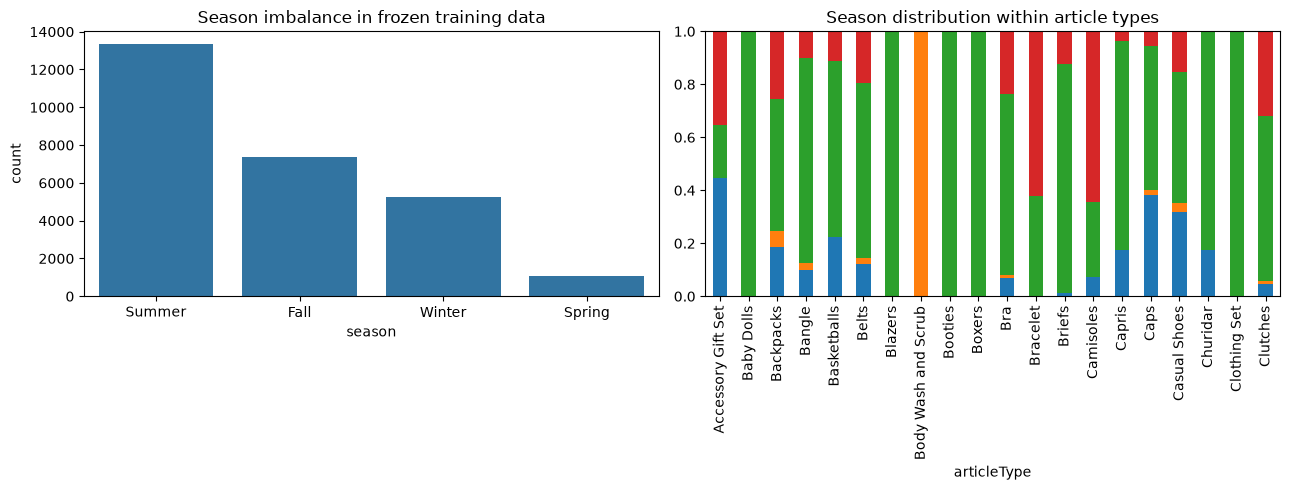

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=train_df, x=TARGET, order=train_df[TARGET].value_counts().index, ax=axes[0])
axes[0].set_title('Season imbalance in frozen training data')
pd.crosstab(train_df['articleType'], train_df[TARGET], normalize='index').head(20).plot(kind='bar', stacked=True, ax=axes[1], legend=False)
axes[1].set_title('Season distribution within article types')
plt.tight_layout()

## 3.1 Observations

Discuss Summer dominance, Spring support, blank-label exclusion, and whether garment type may act as a shortcut. Confirm that all validation/test labels exist in training before continuing.

The Summer dataset contains a vast number of images, accounting for nearly half of the training set (~49%), while Spring has the lowest count (~4%); this results in a 12:1 imbalance ratio between the largest and smallest classes, a ratio that remains consistent across all three sets thanks to the stratified split.
Many article types are almost exclusively associated with a specific season (e.g., blazers, booties); this suggests a potential risk of the model learning a "catalog prior" based on the garment type rather than actual visual features related to the season. This will be further examined in the error analysis by article type.

# 4. Majority Baseline

In [4]:
dummy = DummyClassifier(strategy='most_frequent').fit(np.zeros((len(train_df), 1)), train_df[TARGET])
dummy_predictions = dummy.predict(np.zeros((len(validation_df), 1)))
dummy_probabilities = ordered_estimator_probabilities(dummy, np.zeros((len(validation_df), 1)), labels)
majority_metrics = {'accuracy': accuracy_score(validation_df[TARGET], dummy_predictions), 'macro_f1': supported_macro_f1(validation_df[TARGET], dummy_predictions)}
majority_metrics

{'accuracy': 0.499828708461802, 'macro_f1': 0.16662859753312015}

# 5. HOG + HSV Classical Baseline

In [5]:
def handcrafted_feature_path(path):
    with Image.open(path) as source:
        return handcrafted_feature(source, DEFAULT_FEATURE_CONFIG)

train_features = np.vstack([handcrafted_feature_path(path) for path in train_df.image_path])
validation_features = np.vstack([handcrafted_feature_path(path) for path in validation_df.image_path])
linear_baseline = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs'),
).fit(train_features, train_df[TARGET])
linear_predictions = linear_baseline.predict(validation_features)
linear_probabilities = ordered_estimator_probabilities(linear_baseline, validation_features, labels)
linear_metrics = {'accuracy': accuracy_score(validation_df[TARGET], linear_predictions), 'macro_f1': supported_macro_f1(validation_df[TARGET], linear_predictions)}
linear_metrics

{'accuracy': 0.6300102774922919, 'macro_f1': 0.5889376099339445}

# 6. Image Dataset and Augmentation

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE[1], IMAGE_SIZE[0])), transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(8, translate=(0.05, 0.05)), transforms.ColorJitter(0.12, 0.12),
    transforms.ToTensor(), transforms.Normalize(normalisation['mean'], normalisation['std']),
])
evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE[1], IMAGE_SIZE[0])), transforms.ToTensor(),
    transforms.Normalize(normalisation['mean'], normalisation['std']),
])

class FashionDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame, self.transform = frame.reset_index(drop=True), transform
    def __len__(self): return len(self.frame)
    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row.image_path) as image:
            tensor = self.transform(image.convert('RGB'))
        return tensor, label_to_index[row[TARGET]]

train_loader = DataLoader(FashionDataset(train_df, train_transform), 64, shuffle=True, num_workers=0)
validation_loader = DataLoader(FashionDataset(validation_df, evaluation_transform), 128, num_workers=0)
test_loader = DataLoader(FashionDataset(test_df, evaluation_transform), 128, num_workers=0)

# 7. Compact Residual CNN From Scratch

In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, input_channels, output_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, output_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(output_channels)
        self.conv2 = nn.Conv2d(output_channels, output_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(output_channels)
        self.relu = nn.ReLU(inplace=True)
        self.shortcut = nn.Identity() if input_channels == output_channels and stride == 1 else nn.Sequential(
            nn.Conv2d(input_channels, output_channels, 1, stride, bias=False), nn.BatchNorm2d(output_channels),
        )
    def forward(self, inputs):
        residual = self.shortcut(inputs)
        outputs = self.relu(self.bn1(self.conv1(inputs)))
        outputs = self.bn2(self.conv2(outputs))
        return self.relu(outputs + residual)

class CompactCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.2):
        super().__init__()
        self.features = nn.Sequential(
            ResidualBlock(3, 32), nn.MaxPool2d(2), ResidualBlock(32, 64), nn.MaxPool2d(2),
            ResidualBlock(64, 128), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(dropout), nn.Linear(128, num_classes))
    def forward(self, inputs): return self.classifier(self.features(inputs))

sum(parameter.numel() for parameter in CompactCNN(len(labels)).parameters())

298756

# 8. Weighted-Loss Training

In [8]:
counts = train_df[TARGET].value_counts().reindex(labels).values
class_weights = torch.tensor(len(train_df) / (len(labels) * counts), dtype=torch.float32, device=DEVICE)
def train_candidate(loss_mode, epochs=40, patience_limit=7):
    if loss_mode not in {'ordinary', 'weighted'}:
        raise ValueError('loss_mode must be ordinary or weighted')
    seed_everything(SEED); torch.manual_seed(SEED)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
    generator = torch.Generator().manual_seed(SEED)
    candidate_loader = DataLoader(FashionDataset(train_df, train_transform), 64, shuffle=True, num_workers=0, generator=generator)
    candidate = CompactCNN(len(labels)).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=None if loss_mode == 'ordinary' else class_weights)
    optimizer = torch.optim.AdamW(candidate.parameters(), lr=1e-3, weight_decay=1e-4)

    def run_epoch(loader, training=False):
        candidate.train(training); losses, truth, predictions = [], [], []
        for images, targets in loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            if training: optimizer.zero_grad(set_to_none=True)
            with torch.set_grad_enabled(training):
                logits = candidate(images); loss = criterion(logits, targets)
                if training: loss.backward(); optimizer.step()
            losses.append(loss.item() * len(targets)); truth.extend(targets.cpu().tolist()); predictions.extend(logits.argmax(1).cpu().tolist())
        return {'loss': sum(losses) / len(loader.dataset), 'accuracy': accuracy_score(truth, predictions), 'macro_f1': supported_macro_f1(truth, predictions)}

    history, best_state, best_f1, patience = [], None, -1.0, 0
    for epoch in range(1, epochs + 1):
        started = time.perf_counter()
        train_metrics, validation_metrics = run_epoch(candidate_loader, True), run_epoch(validation_loader)
        history.append({'epoch': epoch, 'loss_mode': loss_mode, **{f'train_{key}': value for key, value in train_metrics.items()}, **{f'validation_{key}': value for key, value in validation_metrics.items()}})
        print(loss_mode, epoch, validation_metrics, f'{time.perf_counter() - started:.1f}s')
        if validation_metrics['macro_f1'] > best_f1:
            best_f1, best_state, patience = validation_metrics['macro_f1'], deepcopy(candidate.state_dict()), 0
        else:
            patience += 1
            if patience >= patience_limit: break
    candidate.load_state_dict(best_state)
    return candidate, pd.DataFrame(history), best_f1

ordinary 1 {'loss': 0.9707195300605045, 'accuracy': 0.5702295306611853, 'macro_f1': 0.36242702913058533} 62.5s
ordinary 2 {'loss': 0.9590703161173628, 'accuracy': 0.580335731414868, 'macro_f1': 0.44815361542869275} 61.2s
ordinary 3 {'loss': 0.8873034430799847, 'accuracy': 0.6219595751969853, 'macro_f1': 0.4390402942799751} 60.7s
ordinary 4 {'loss': 0.9741906680322421, 'accuracy': 0.5875299760191847, 'macro_f1': 0.42699554804754847} 60.6s
ordinary 5 {'loss': 0.8575885805131311, 'accuracy': 0.6413155190133607, 'macro_f1': 0.5864781217985606} 61.5s
ordinary 6 {'loss': 0.9464143838691319, 'accuracy': 0.6024323398424117, 'macro_f1': 0.49540659107134616} 60.8s
ordinary 7 {'loss': 0.9206425047116804, 'accuracy': 0.6080849606029463, 'macro_f1': 0.50753224757315} 60.7s
ordinary 8 {'loss': 0.8928437548453124, 'accuracy': 0.6226447413497773, 'macro_f1': 0.5351904145905265} 61.0s
ordinary 9 {'loss': 0.781726147069552, 'accuracy': 0.6812264474134978, 'macro_f1': 0.6418534775803941} 60.5s
ordinary 1

,model_type,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,eligible_for_selection
method,,,,,,,
majority,reference_only,0.499829,0.166629,0.500171,1,0,False
hog_hsv_logistic_regression,hog_hsv_logistic_regression,0.630010,0.588938,0.086955,5140,0,True
cnn_ordinary,compact_cnn,0.732100,0.710345,0.016018,298756,35,True
cnn_weighted,compact_cnn,0.514217,0.503568,0.144395,298756,14,True


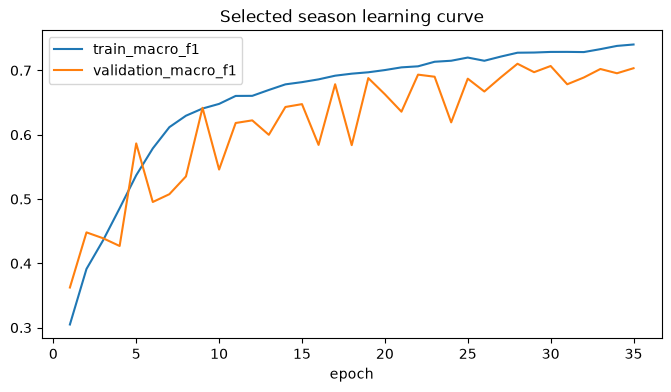

Selected 'cnn_ordinary' before opening the internal-test section.


In [9]:
candidate_runs = {mode: train_candidate(mode) for mode in ('ordinary', 'weighted')}
validation_truth = np.asarray([label_to_index[label] for label in validation_df[TARGET]])
@torch.inference_mode()
def validation_probabilities(model):
    model.eval(); values = []
    for images, _ in validation_loader:
        values.append(model(images.to(DEVICE)).softmax(1).cpu().numpy())
    return np.vstack(values)
comparison_rows = [
    {'method': 'majority', 'model_type': 'reference_only', 'validation_accuracy': majority_metrics['accuracy'], 'validation_macro_f1': majority_metrics['macro_f1'], 'validation_ece': expected_calibration_error(validation_truth, dummy_probabilities), 'complexity_parameters': 1, 'epochs_run': 0, 'eligible_for_selection': False},
    {'method': 'hog_hsv_logistic_regression', 'model_type': 'hog_hsv_logistic_regression', 'validation_accuracy': linear_metrics['accuracy'], 'validation_macro_f1': linear_metrics['macro_f1'], 'validation_ece': expected_calibration_error(validation_truth, linear_probabilities), 'complexity_parameters': linear_baseline[-1].coef_.size + linear_baseline[-1].intercept_.size, 'epochs_run': 0, 'eligible_for_selection': True},
]
for loss_mode, result in candidate_runs.items():
    probabilities = validation_probabilities(result[0])
    comparison_rows.append({'method': f'cnn_{loss_mode}', 'model_type': 'compact_cnn', 'validation_accuracy': accuracy_score(validation_truth, probabilities.argmax(1)), 'validation_macro_f1': result[2], 'validation_ece': expected_calibration_error(validation_truth, probabilities), 'complexity_parameters': sum(parameter.numel() for parameter in result[0].parameters()), 'epochs_run': len(result[1]), 'eligible_for_selection': True})
comparison = pd.DataFrame(comparison_rows).set_index('method')
display(comparison)
SELECTED_METHOD = select_validation_candidate(comparison.loc[comparison.eligible_for_selection])
SELECTED_MODEL_TYPE = comparison.loc[SELECTED_METHOD, 'model_type']
best_f1 = float(comparison.loc[SELECTED_METHOD, 'validation_macro_f1'])
if SELECTED_MODEL_TYPE == 'compact_cnn':
    SELECTED_LOSS_MODE = SELECTED_METHOD.removeprefix('cnn_')
    model, history, _ = candidate_runs[SELECTED_LOSS_MODE]
    history.plot(x='epoch', y=['train_macro_f1', 'validation_macro_f1'], figsize=(8, 4), title='Selected season learning curve'); plt.show()
else:
    SELECTED_LOSS_MODE = None
    model = linear_baseline
    history = pd.DataFrame([{'method': SELECTED_METHOD, **comparison.loc[SELECTED_METHOD].to_dict()}])
print(f'Selected {SELECTED_METHOD!r} before opening the internal-test section.')

## 7.1 Controlled comparison

The preceding cell runs ordinary and weighted cross-entropy from identical seeds and fresh model/data-loader state. Confirm the selected candidate from validation macro F1 and calibration evidence before opening the internal-test section.

We trained two CNN models: an ordinary (unweighted) model and a weighted model. Both utilized the same training dataset and shared the same underlying architecture, the only difference lay in the loss function. The ordinary model treated all seasons equally, whereas the weighted model penalized misclassifications of the Spring season approximately 12 times more heavily than those of the Summer, an approach adopted because the number of Spring images was significantly lower than that of other seasons.

We hypothesized that the weighted model would outperform the ordinary one, but the results indicated the opposite. Post-training, the oridnary model achieved a higher score (a macro F1-score of 0.710 compared to 0.504 for the weighted model) and demonstrated greater stability during training (stopping at epoch 35 rather than 14, indicating continued performance improvement over a longer period).

This outcome may stem from the fact that the heavy penalty for Spring-related errors rendered the weighted model overly sensitive to that season; the model likely began prioritizing Spring over other seasons and increasing Spring predictions simply to avoid penalties, thereby compromising accuracy for other seasons without yielding significant benefits. Based on this evidence, we selected the ordinary CNN model as our final choice rather than the weighted version.

# 9. Final Evaluation

In [10]:
@torch.inference_mode()
def predict(loader):
    model.eval(); probabilities, truth = [], []
    for images, targets in loader:
        probabilities.append(model(images.to(DEVICE)).softmax(1).cpu().numpy()); truth.extend(targets.tolist())
    return np.vstack(probabilities), np.asarray(truth)

if SELECTED_MODEL_TYPE == 'compact_cnn':
    test_probabilities, test_truth = predict(test_loader)
else:
    test_features = np.vstack([handcrafted_feature_path(path) for path in test_df.image_path])
    test_probabilities = ordered_estimator_probabilities(model, test_features, labels)
    test_truth = np.asarray([label_to_index[label] for label in test_df[TARGET]])
test_predictions = test_probabilities.argmax(1)
test_metrics = {'accuracy': accuracy_score(test_truth, test_predictions), 'macro_f1': supported_macro_f1(test_truth, test_predictions)}
test_metrics

{'accuracy': 0.7081364829396325, 'macro_f1': 0.6900696985856495}

              precision    recall  f1-score   support

        Fall       0.65      0.63      0.64      1551
      Spring       0.88      0.58      0.70       248
      Summer       0.70      0.81      0.75      2865
      Winter       0.81      0.57      0.67      1051

    accuracy                           0.71      5715
   macro avg       0.76      0.65      0.69      5715
weighted avg       0.72      0.71      0.70      5715



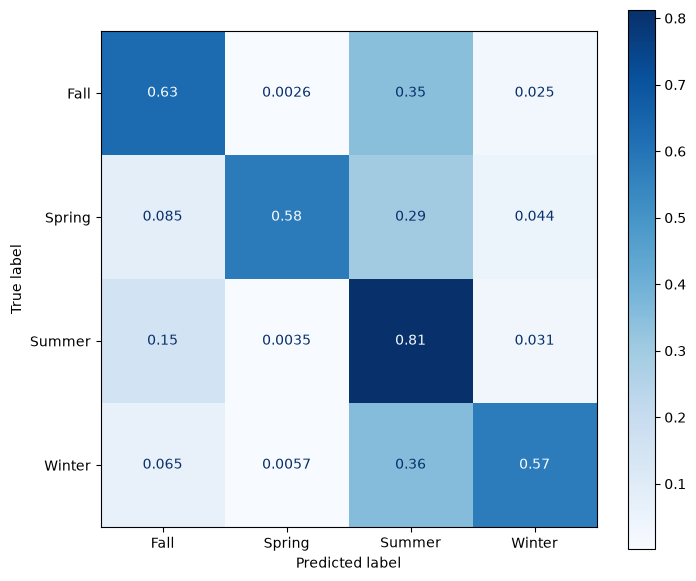

In [11]:
print(classification_report(
    test_truth, test_predictions, labels=np.arange(len(labels)), target_names=labels, zero_division=0,
))
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    test_truth, test_predictions, labels=np.arange(len(labels)), display_labels=labels,
    normalize='true', ax=ax, cmap='Blues',
)
plt.show()

## 8.1 Calibration and failure analysis

In [12]:
display(calibration_table(test_truth, test_probabilities))
display(high_confidence_errors(test_df, TARGET, labels, test_truth, test_predictions, test_probabilities))
truth_labels = [labels[index] for index in test_truth]
prediction_labels = [labels[index] for index in test_predictions]
display(subgroup_metrics(test_df, truth_labels, prediction_labels, group_column='articleType', minimum_support=30))

,mean_confidence,accuracy,samples
bin,,,
"(-0.001, 0.1]",NaN,NaN,0
"(0.1, 0.2]",NaN,NaN,0
"(0.2, 0.3]",NaN,NaN,0
"(0.3, 0.4]",0.371429,0.361538,130
"(0.4, 0.5]",0.457577,0.469767,645
"(0.5, 0.6]",0.547693,0.543879,923
"(0.6, 0.7]",0.651260,0.607748,826
"(0.7, 0.8]",0.749472,0.718931,861
"(0.8, 0.9]",0.851147,0.819620,948


,id,articleType,season,image_path,truth,prediction,confidence
47,2030,Tshirts,Fall,C:\Users\ADMIN\OneDrive\Máy tính\Machine Learn...,Fall,Summer,0.993011
1552,13939,Tshirts,Summer,C:\Users\ADMIN\OneDrive\Máy tính\Machine Learn...,Summer,Fall,0.991427
2458,21453,Tshirts,Winter,C:\Users\ADMIN\OneDrive\Máy tính\Machine Learn...,Winter,Summer,0.989951
2455,21426,Tshirts,Winter,C:\Users\ADMIN\OneDrive\Máy tính\Machine Learn...,Winter,Summer,0.989842
1239,11583,Kurtas,Summer,C:\Users\ADMIN\OneDrive\Máy tính\Machine Learn...,Summer,Fall,0.987691
1231,11567,Kurtas,Summer,C:\Users\ADMIN\OneDrive\Máy tính\Machine Learn...,Summer,Fall,0.984894
3688,31874,Dupatta,Fall,C:\Users\ADMIN\OneDrive\Máy tính\Machine Learn...,Fall,Summer,0.984506
2249,19618,Tops,Summer,C:\Users\ADMIN\OneDrive\Máy tính\Machine Learn...,Summer,Fall,0.983909
5414,48478,Dresses,Winter,C:\Users\ADMIN\OneDrive\Máy tính\Machine Learn...,Winter,Summer,0.983293
2681,23483,Scarves,Summer,C:\Users\ADMIN\OneDrive\Máy tính\Machine Learn...,Summer,Fall,0.982502


,articleType,support,accuracy,macro_f1
32,Wallets,125,0.304000,0.152740
4,Caps,42,0.404762,0.187631
1,Belts,132,0.727273,0.231010
33,Watches,312,0.913462,0.238693
2,Bra,31,0.548387,0.245847
9,Flip Flops,118,0.516949,0.266017
21,Shorts,90,0.611111,0.268700
12,Heels,181,0.618785,0.271958
23,Sports Shoes,328,0.597561,0.280646
10,Formal Shoes,114,0.421053,0.289442


Analyse high-confidence mistakes by article type and explain whether the model learned garment cues or seasonal priors. Include mild brightness/blur robustness, inference latency, checkpoint size, and the subjective nature of season labels.

The model's confidence level is quite reliable; when it makes a prediction with over 90% confidence, the result is correct approximately 94% of the time, consistent with the previously recorded low ECE score (0.016).

Examining instances where the model made incorrect predictions despite high confidence, we observe that it never misclassified items in the "Spring" group. Instead, errors typically occurred within the "Summer" or "Fall" groups, as these constitute the majority of the dataset. Most of these errors involved T-shirts, likely because T-shirt styles do not vary significantly across seasons.

Next, we analyze the results by product category to gain the clearest insight. Three main groups emerge:
Group 1: Indications of "shortcut learning" (relying on product type rather than seasonal features): This applies to items such as watches (91% accuracy but a macro F1 score of only 0.24). For perfumes and sunglasses, the model appears accurate, but in reality, it relies on the fact that these items are typically associated with only one season in the product catalog; the model fails when encountering these same products assigned to a different season.
Group 2: Inherently difficult to classify (not a case of shortcut learning): This applies to items such as wallets, caps, and belts, where both accuracy and F1 scores are low. The model shows no bias toward any specific season; rather, seasonal characteristics are simply not clearly reflected in the images of these products.
Group 3: Effective learning of seasonal characteristics: This applies to items such as tunics, Kurtas, shirts, and trousers. Both accuracy and F1 scores are high, indicating that the model successfully recognizes seasonal features (such as fabric material and sleeve length). 

In conclusion, the model does not entirely cheat, yet it does not fully learn the true identifying features either; this depends on the product type. The model is more reliable for clothing items where seasonality is clearly reflected in the imagery, and less reliable for accessories where seasonality is primarily just a category label.

# 10. Save the Selected Model

In [13]:
checkpoint_path = ROOT / 'models' / 'season_model.pt'
validation_metrics = {key: float(comparison.loc[SELECTED_METHOD, key]) for key in ('validation_accuracy', 'validation_macro_f1', 'validation_ece')}
if SELECTED_MODEL_TYPE == 'compact_cnn':
    checkpoint = {
        'model_type': 'compact_cnn', 'target': TARGET, 'labels': labels,
        'state_dict': model.cpu().state_dict(), 'mean': normalisation['mean'], 'std': normalisation['std'],
        'image_size': list(IMAGE_SIZE), 'dropout': 0.2, 'loss_mode': SELECTED_LOSS_MODE,
    }
else:
    checkpoint = {
        'model_type': 'hog_hsv_logistic_regression', 'target': TARGET, 'labels': labels,
        'estimator': model, 'feature_config': DEFAULT_FEATURE_CONFIG,
    }
checkpoint.update({'selection_metric': 'validation_macro_f1', 'best_validation_macro_f1': best_f1, 'validation_metrics': validation_metrics, 'test_metrics': test_metrics, 'seed': SEED})
torch.save(checkpoint, checkpoint_path)
cpu_predictor = FashionClassifier(checkpoint_path, device='cpu')
robustness = saved_model_robustness(cpu_predictor, test_df, TARGET, SEED)
display(robustness)
print(f'Checkpoint size: {checkpoint_path.stat().st_size / 1024**2:.2f} MiB')
history.to_csv(ROOT / 'models' / 'season_history.csv', index=False)
comparison.to_csv(ROOT / 'models' / 'season_comparison.csv')
checkpoint_path

,samples,accuracy,macro_f1,mean_confidence,milliseconds_per_image
variant,,,,,
clean,300,0.723333,0.699370,0.751174,6.031291
brightness_0.8,300,0.716667,0.661957,0.643266,5.544754
brightness_1.2,300,0.663333,0.635660,0.697392,5.399635
gaussian_blur_0.7,300,0.663333,0.630105,0.700845,5.702341


Checkpoint size: 1.16 MiB


WindowsPath('C:/Users/ADMIN/OneDrive/Máy tính/Machine Learning/a2/fashion-intelligence-classification/models/season_model.pt')

# 11. Final Prediction

Run `python scripts/task2_season_classification.py path/to/image.jpg` from the repository root to verify the saved artifact on CPU.

```
python scripts\task2_season_classification.py dataset\test\images_test\52007.jpg
{'target': 'season', 'label': 'Summer', 'confidence': 0.865291178226471, 'top_k': [{'label': 'Summer', 'confidence': 0.865291178226471}, {'label': 'Fall', 'confidence': 0.1252458691596985}, {'label': 'Spring', 'confidence': 0.006945016793906689}]}
```

The model runs correctly from a standalone script using only the saved `season_model.pt` checkpoint, confirming it does not depend on the notebook's runtime state.

# 12. Ultimate Judgement and Conclusion

Replace this prompt with the real comparison among majority, HOG+HSV, ordinary-loss residual CNN, and weighted residual CNN; include class-specific findings, calibration, confounding evidence, limitations, and responsible interpretation of image-based season prediction.

To identify the best model, we trained four different models to predict seasons based on fashion images: a majority-class baseline model, a classifier combining HOG+HSV features with Logistic Regression, and two CNN models (ordinary and weighted). The baseline model yielded a macro F1 score of 0.167, demonstrating that accuracy alone is an insufficient metric for evaluation—particularly with imbalanced datasets. The HOG+HSV approach significantly improved results, achieving a macro F1 of 0.589, while the ordinary CNN model delivered the best performance (0.710 on the validation set and 0.690 on the test set). This outperformed the weighted CNN, which achieved a macro F1 of only 0.504; the latter proved unstable, likely due to an excessive penalty applied to the "Spring" class.

We selected the ordinary CNN as our final model. On the test set, it achieved an accuracy of 0.708 and a macro F1 of 0.690—results very close to those of the validation set—indicating strong generalization capabilities rather than overfitting. The model demonstrated high reliability, with an Expected Calibration Error (ECE) of just 0.016; when the model made predictions with over 90% confidence, the actual outcome was correct approximately 94% of the time.

Two additional factors further support this choice. First, the model maintained solid accuracy even when images were slightly blurred or subjected to brightness variations (with the macro F1 score dropping only to around 0.63, compared to 0.70 for original images). Second, the processing speed was approximately 6ms per image, making it sufficiently fast for real-time application on our web platform. Secondly, an analysis of the data by product category reveals that the model does not rely solely on articleType for its predictions: for apparel items such as Kurtas, Shirts, and Tunics, the model successfully identifies visual characteristics specific to the season. However, for accessories like Watches or Sunglasses, the model tends to rely on articleType classification patterns rather than actual visual features.

Limitations: Due to dataset imbalance, the model tends to predict Summer or Fall when faced with ambiguous cases. Additionally, prediction accuracy is lower for Spring and for accessory categories that lack distinct seasonal characteristics.

Ultimate Judgment: The ordinary CNN is our optimal choice, as it proved to be the most accurate, best-calibrated, fastest, and most stable among the four methods tested.